
# MVP: *Machine Learning & Analytics*
**Nome:** _Natália Gottardo Costa Oliveira_  

**Data:** 27/08/2025

**Matrícula:** 4052025001154

**Dataset:** [Amazon Fine Food Reviews](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews)


---



## 1. Escopo, objetivo e definição do problema
 Objetivo: Dado o texto de uma review de comida da Amazon,
prever se o sentimento é positivo ou negativo.

Valor: Monitorar satisfação de clientes, automatizar feedbacks, etc.



## 2. Setup e reprodutibilidade


In [93]:
# === Setup e reprodutibilidade ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string
import time
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

SEED = 42
np.random.seed(SEED)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


##2.1 Funções úteis





In [94]:
# === Funções utilitárias ===
STOP = set(stopwords.words("english"))

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', s)
    s = re.sub(r'\d+', '', s)
    tokens = [t for t in s.split() if t not in STOP and len(t) > 1]
    return ' '.join(tokens)

def evaluate_classification(y_true, y_pred, proba=None):
    acc = accuracy_score(y_true, y_pred)
    f1w = f1_score(y_true, y_pred, average="weighted")
    auc = None
    try:
        if proba is not None:
            auc = roc_auc_score(y_true, proba[:,1])
    except Exception:
        auc = None
    return {"accuracy": acc, "f1_weighted": f1w, "roc_auc": auc}


##3. Carga dos dados


In [95]:
# === Carga dos dados ===
import pandas as pd
from google.colab import drive

# Monta o Google Drive
drive.mount("/content/drive")

# Caminho para o CSV no Drive
file_path = "/content/drive/MyDrive/Reviews.csv"

# Lê o CSV com encoding adequado
df = pd.read_csv(file_path, encoding="latin1")

# Remove espaços extras nos nomes das colunas
df.rename(columns=lambda x: x.strip(), inplace=True)

# Verifica o tipo e primeiras linhas
print(type(df))
df.head()





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


**Origem:** Amazon Fine Food Reviews (Kaggle).  
**Descrição rápida:** colunas principais incluem: Id, ProductId, UserId, ProfileName, HelpfulnessNumerator, HelpfulnessDenominator, Score, Time, Summary, Text.  
**Risco/ética:** dados públicos; cuidado com vieses nas reviews (não representam toda a população).  



## 4. Limpeza e criação do target



In [96]:


# === Limpeza e criação do target ===
# Drop linhas sem texto
df = df.dropna(subset=["Text", "Score"])
print("Depois dropna:", df.shape)

# Filtrar neutros (Score == 3)
df = df[df["Score"] != 3].copy()

# Criar target: 1 para score 4-5, 0 para score 1-2
df["Sentiment"] = df["Score"].apply(lambda x: 1 if x > 3 else 0)

# Texto limpo
df["text_clean"] = df["Text"].apply(clean_text)

# Criar coluna com número de palavras
df["n_words"] = df["text_clean"].str.split().apply(len)

# Estatísticas básicas
print("Distribuição das classes:")
print(df["Sentiment"].value_counts(normalize=True))
df[["Score","Sentiment","text_clean","n_words"]].head()





Depois dropna: (568454, 10)
Distribuição das classes:
Sentiment
1    0.843981
0    0.156019
Name: proportion, dtype: float64


,Score,Sentiment,text_clean,n_words
0,5,1,bought several vitality canned dog food produc...,23
1,1,0,product arrived labeled jumbo salted peanuts p...,18
2,4,1,confection around centuries light pillowy citr...,39
3,2,0,looking secret ingredient robitussin believe f...,18
4,5,1,great taffy great price wide assortment yummy ...,13



## 5. EDA Resumido



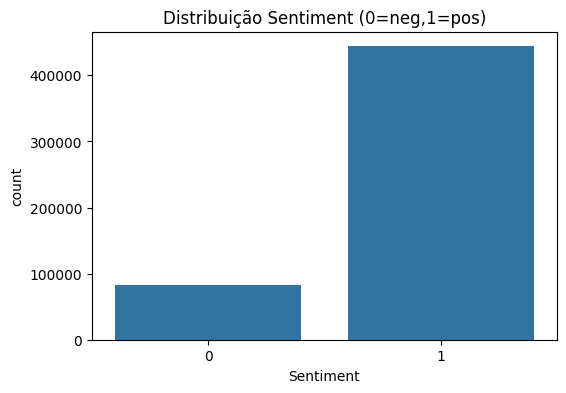

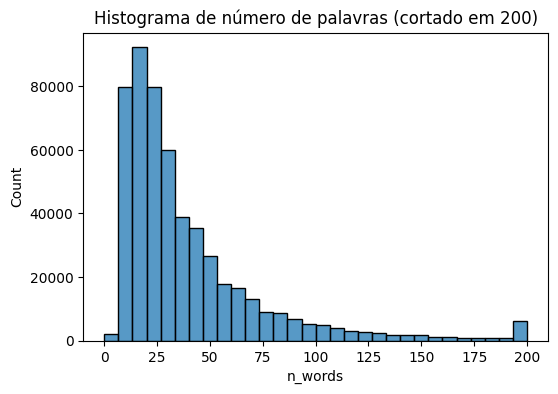

Top 15 palavras: [('br', 579855), ('like', 229727), ('good', 181893), ('one', 162055), ('great', 159548), ('taste', 153102), ('product', 151813), ('coffee', 148637), ('flavor', 131367), ('tea', 127562), ('love', 121310), ('food', 119740), ('would', 108746), ('amazon', 99661), ('get', 98782)]


In [97]:
# === EDA resumido ===
plt.figure(figsize=(6,4))
sns.countplot(x="Sentiment", data=df)
plt.title("Distribuição Sentiment (0=neg,1=pos)")
plt.show()

# Distribuição do tamanho dos textos
df["n_words"] = df["text_clean"].str.split().apply(lambda x: len(x) if isinstance(x, list) else 0)
plt.figure(figsize=(6,4))
sns.histplot(df["n_words"].clip(0,200), bins=30)
plt.title("Histograma de número de palavras (cortado em 200)")
plt.show()

# Top palavras (simples)
from collections import Counter
all_tokens = " ".join(df["text_clean"].dropna().values).split()
freq = Counter(all_tokens)
print("Top 15 palavras:", freq.most_common(15))



## 6. Divisão treino/validação/teste


In [98]:
# === Divisão treino/val/test (estratificado) ===
X = df["text_clean"]
y = df["Sentiment"]

# split test 10%
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=SEED, stratify=y)
# split val 11.11% of remaining => ~10% total
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.111111, random_state=SEED, stratify=y_temp)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train class dist:", y_train.value_counts(normalize=True).to_dict())


Train: (420650,) Val: (52582,) Test: (52582,)
Train class dist: {1: 0.8439819327231666, 0: 0.15601806727683348}



## 7. Pipelines, Baseline e Modelos Candidatos



In [99]:
# === Pipelines e treino rápido (baseline + candidatos) ===
pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words="english")),
    ("clf", MultinomialNB())
])
pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1,2), stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
])

models = {"NaiveBayes": pipe_nb, "LogisticRegression": pipe_lr}

results_quick = {}
for name, p in models.items():
    t0 = time.time()
    p.fit(X_train, y_train)
    t1 = time.time()
    y_pred = p.predict(X_val)
    results_quick[name] = evaluate_classification(y_val, y_pred, proba = p.predict_proba(X_val) if hasattr(p, "predict_proba") else None)
    results_quick[name]["train_time_s"] = round(t1-t0,3)

import pandas as pd
pd.DataFrame(results_quick).T


,accuracy,f1_weighted,roc_auc,train_time_s
NaiveBayes,0.904055,0.889675,0.950105,60.732
LogisticRegression,0.940208,0.937591,0.968117,72.659


## 8. Hyperparam Tuning



In [100]:
# === Hyperparam tuning (RandomizedSearchCV) ===
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

param_dist_lr = {
    "tfidf__max_features": [5000, 10000, 20000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__C": [0.01, 0.1, 1, 10]
}

model_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
])

search = RandomizedSearchCV(model_pipeline, param_distributions=param_dist_lr,
                            n_iter=8, cv=cv, scoring="f1_weighted", random_state=SEED, n_jobs=-1, verbose=1)
t0 = time.time()
search.fit(X_train, y_train)
t1 = time.time()
print("Tempo tuning (s):", round(t1-t0,1))
print("Melhor score CV:", search.best_score_)
print("Melhores params:", search.best_params_)
best_model = search.best_estimator_


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Tempo tuning (s): 794.6
Melhor score CV: 0.9276141579340065
Melhores params: {'tfidf__ngram_range': (1, 1), 'tfidf__max_features': 20000, 'clf__C': 1}


## 9. Avaliação Final e Análise de Erros

=== Resultado final (test set) ===
accuracy       0.934331
f1_weighted    0.931459
roc_auc        0.961276
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0     0.8573    0.6948    0.7675      8204
           1     0.9455    0.9786    0.9618     44378

    accuracy                         0.9343     52582
   macro avg     0.9014    0.8367    0.8646     52582
weighted avg     0.9317    0.9343    0.9315     52582



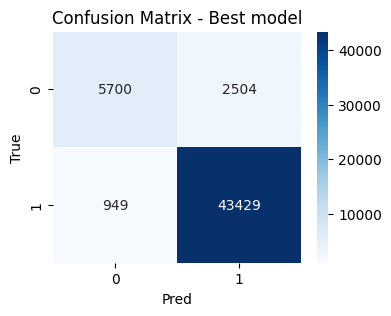

,text,true,pred
157084,first good stuff coffee smooth even hint bitte...,0,1
544721,purchasing product many years help little dog ...,1,0
480064,purchased good chipotle sauce find found stuff...,0,1
137774,brought times honestly even saw jax sale cheap...,1,0
207739,rabbit named clover br sold amazon br said fre...,0,1
55520,ordinarily eat plain cheerios oatmeal breakfas...,0,1
218969,breakfast blend longer mild coffee flavor come...,0,1
160055,freeze dried mushrooms prior could kept pantry...,0,1
237308,looking reviews saying quantity packages opene...,1,0
363971,received item labeled sea salt fact sea salt v...,0,1


In [101]:
# === Re-treinar em treino+val e avaliar em test ===
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_model.fit(X_train_full, y_train_full)

y_test_pred = best_model.predict(X_test)
proba_test = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None

print("=== Resultado final (test set) ===")
print(pd.Series(evaluate_classification(y_test, y_test_pred, proba_test)))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred, digits=4))

# Matriz de confusão
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Best model")
plt.xlabel("Pred")
plt.ylabel("True")
plt.show()

# Mostrar alguns exemplos mal classificados (10 amostras)
mis = y_test != y_test_pred
misses = pd.DataFrame({"text": X_test[mis], "true": y_test[mis], "pred": y_test_pred[mis]})
if len(misses)>0:
    display(misses.sample(min(10, len(misses))))
else:
    print("Nenhum mal classificado no hold-out (raríssimo).")



## 10. Engenharia de atributos



In [102]:
# === Engenharia de atributos ===
# Já temos n_words. Podemos experimentar usar n_words como feature extra.
print("Exemplo: média de palavras por classe")
display(df.groupby("Sentiment")["n_words"].describe())


Exemplo: média de palavras por classe


,count,mean,std,min,25%,50%,75%,max
Sentiment,,,,,,,,
0,82037.0,44.302766,46.891579,1.0,18.0,31.0,53.0,1140.0
1,443777.0,39.388044,40.989632,0.0,16.0,27.0,47.0,1673.0


## 11. Salvar Artefatos

In [103]:
# === Salvar artefatos ===
import os
import joblib
os.makedirs("artifacts", exist_ok=True)
joblib.dump(best_model, "artifacts/best_model.pkl")
joblib.dump(search.best_params_, "artifacts/best_params.pkl")
print("Modelos salvos em /artifacts")


Modelos salvos em /artifacts



## 12. Checklist



- Problema definido: sim (sentiment classification).
- Carga/prep: dados carregados do CSV, removi neutros (score==3), limpei texto.
- Divisão: treino/val/test estratificado (80/10/10).
- Tratamento: TF-IDF + pipelines; limpeza de texto; n_words como feature exploratória.
- Modelagem: baseline NB e candidato Logistic; HPO com RandomizedSearchCV.
- Métricas: F1-weighted, accuracy e matriz de confusão.
- Boas práticas: seed fixa, pipelines, salvar artefatos.



## 13. Conclusões e próximos passos



Resumo: Logistic Regression com TF-IDF (parâmetros otimizados) foi o melhor modelo no hold-out.
Limitações: removi neutros (poderiam ser tratados como terceira classe), não testei modelos baseados em embeddings (BERT) por limitação de tempo.
Próximos passos: experimentar embeddings contextualizados, explicabilidade (SHAP) e pipeline de monitoramento (drift).
